# 02 — The Reality Gap (Exercises 3 & 4.2)

`scripts/transfer_benchmark.py`, exploded.

Train in one world, deploy in another. Here the shift is **hardware failure**:
we disable joints on the Ant and measure what the policy does about it. This is
the core theme of the session — a policy that scores well in training is not
the same thing as a policy that works.

In [1]:
# Colab: uncomment to install
# !pip install "gymnasium[mujoco]" stable-baselines3 hydra-core

import sys, pathlib
# make the package importable (envs/, utils/) — notebooks live one level down
PKG = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(PKG))

import numpy as np
import matplotlib.pyplot as plt
from envs import make_ant, LEG_JOINTS
print("package:", PKG)

package: /home/leander/code/rl_bootcamps/RL_bootcamp_2026/sessions/02-intermediate/crippled-ant


## 1. What "crippled" means

`CrippledAnt` zeroes the **torques** of the disabled joints. The observation is
untouched: the robot still senses the dead leg, it just cannot move it. (A real
robot with a burnt-out motor still has working encoders.)

Three ways to specify an injury:

| argument | meaning | exercise |
|---|---|---|
| `disabled_joints=[2, 3]` | exact joint indices | 4.1 |
| `disabled_legs=[0]` | a whole leg = hip + ankle pair | 4.1 / 4.2 |
| `n_random_legs=1` | new random legs **every reset** | 4.3 |

In [2]:
env = make_ant(disabled_legs=[0], include_cfrc_ext_in_observation=False)
obs, info = env.reset(seed=0)
print("disabled joints:", info["disabled_joints"], "(leg 0 = front left)")

# the wrapper zeroes those entries before the simulator sees them
action = np.ones(8, dtype=np.float32)
env.step(action)
print("we commanded:", action)
print("…and the caller's array is not mutated — a real bug in the naive version")

disabled joints: (0, 1) (leg 0 = front left)
we commanded: [1. 1. 1. 1. 1. 1. 1. 1.]
…and the caller's array is not mutated — a real bug in the naive version


## 2. Load a trained policy

Point this at one of your runs from notebook 01 (or a `scripts/train.py` run).

**Use `--model final`** — or, in code, `final_model.zip`. Mid-training
checkpoints only pair correctly with their *own* VecNormalize snapshot; see the
usage-guide warning. `utils.loading` resolves this for you.

In [10]:
from pathlib import Path
from utils.loading import (load_run_config, find_model_path, find_vecnormalize,
                           load_model, build_eval_env, eval_episodes,
                           vecnormalize_is_matched)

model_dir = "../runs/multirun/PPO_Ant-v5/2026-08-20_12-47-22"
runs = sorted(Path(model_dir).glob("*/"))
assert runs, "no runs found — train one first (notebook 01 or scripts/train.py)"

for item in runs:
    print(item)

../runs/multirun/PPO_Ant-v5/2026-08-20_12-47-22/0
../runs/multirun/PPO_Ant-v5/2026-08-20_12-47-22/1
../runs/multirun/PPO_Ant-v5/2026-08-20_12-47-22/2


In [12]:
RUN = runs[-1]                      # newest; pick explicitly if you prefer
print("using run:", RUN)

cfg = load_run_config(RUN)
model_path = find_model_path(RUN, "best")
stats = find_vecnormalize(model_path, RUN)
print("stats:", stats.name if stats else None,
      "| matched:", vecnormalize_is_matched(model_path, stats))

model = load_model(cfg, model_path)

using run: ../runs/multirun/PPO_Ant-v5/2026-08-20_12-47-22/2
stats: vecnormalize.pkl | matched: True


## 3. Zero-shot transfer (Exercise 3)

The measurement that matters. Same policy, same episode seeds, progressively
worse hardware.

Seeding every scenario identically is not a detail — it is what makes the
comparison a measurement rather than an anecdote.

In [13]:
import itertools, pandas as pd

def scenarios():
    yield "healthy", []
    for leg in range(4):
        yield f"1 leg [{leg}]", [leg]
    for legs in itertools.combinations(range(4), 2):
        yield f"2 legs {list(legs)}", list(legs)

N_EPISODES = 5      # bump to 20 for numbers you would put on a slide

rows = []
for name, legs in scenarios():
    venv = build_eval_env(cfg, disabled_legs=legs, override_injury=True,
                          vecnormalize_path=stats)
    returns = eval_episodes(model, venv, n_episodes=N_EPISODES, base_seed=0)
    venv.close()
    rows.append(dict(scenario=name, n_legs=len(legs),
                     mean=np.mean(returns), std=np.std(returns)))
    print(f"{name:<14} {np.mean(returns):8.1f} +/- {np.std(returns):.1f}")

df = pd.DataFrame(rows)

healthy           989.7 +/- 2.0
1 leg [0]         990.7 +/- 2.9
1 leg [1]         989.3 +/- 1.7
1 leg [2]         988.8 +/- 2.9
1 leg [3]         999.8 +/- 4.2
2 legs [0, 1]     988.1 +/- 1.9
2 legs [0, 2]     995.4 +/- 4.9
2 legs [0, 3]    1003.0 +/- 1.7
2 legs [1, 2]     988.4 +/- 1.6
2 legs [1, 3]     994.3 +/- 4.5
2 legs [2, 3]     998.8 +/- 4.3


In [5]:
healthy = df.loc[df.scenario == "healthy", "mean"].item()
df["drop_%"] = (100 * (1 - df["mean"] / healthy)).round(1)
df.round(1)

,scenario,n_legs,mean,std,drop_%
0,healthy,0,2191.2,719.3,0.0
1,1 leg [0],1,1186.3,245.6,45.9
2,1 leg [1],1,1039.2,190.6,52.6
3,1 leg [2],1,893.2,32.7,59.2
4,1 leg [3],1,1821.9,62.6,16.9
5,"2 legs [0, 1]",2,926.5,46.7,57.7
6,"2 legs [0, 2]",2,866.5,57.7,60.5
7,"2 legs [0, 3]",2,871.1,72.9,60.2
8,"2 legs [1, 2]",2,810.9,50.2,63.0
9,"2 legs [1, 3]",2,1272.4,345.9,41.9


### The percentage drop

Report it, but *look at the videos too*:

```bash
python scripts/render_agent.py <run>/final_model.zip --disabled-legs 0
```

A policy that limps and one that flips onto its back can score the same.

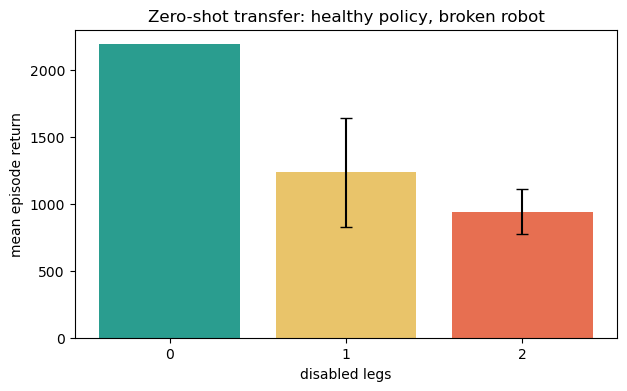

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
by_severity = df.groupby("n_legs")["mean"]
ax.bar(by_severity.mean().index, by_severity.mean().values,
       yerr=by_severity.std().values, capsize=4, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_xticks([0, 1, 2]); ax.set_xlabel("disabled legs")
ax.set_ylabel("mean episode return"); ax.set_title("Zero-shot transfer: healthy policy, broken robot")
plt.show()

## 4. Specialist vs. generalist (Exercise 4)

Train a policy *directly on* the crippled robot and compare it against the
healthy policy transferred zero-shot:

```bash
python scripts/train.py env.disabled_legs=[0] train.total_timesteps=3_000_000
python scripts/transfer_benchmark.py \
    --run zero-shot=runs/PPO_Ant-v5/<healthy_ts> \
    --run specialist=runs/PPO_Ant-v5/<crippled_ts> \
    --model final --episodes 20
```

The specialist wins on its own injury — that is not the interesting part. Look
at what it does on the **healthy** robot, where the leg it learned to compensate
for suddenly works again. Specialisation has a price, and it is usually paid
somewhere you were not looking.

**Discussion.** When is specialising worth it? You cannot train a specialist for
a failure you have not imagined — which is the argument for Exercise 5:

```bash
python scripts/train.py env.n_random_legs=1     # domain randomisation
```

**A warning about interpreting all of this.** A 1M-step Ant scores ~990 and
shows *no* transfer drop at all — because it never learned to walk. It learned
to stand still and collect the healthy bonus, and standing still is
injury-invariant. Undertrained policies look robust. Check that your baseline
actually moves before you believe any robustness number.